In [ ]:
# Helsinki Population Growth Classification Using Machine Learning

# This project analyzes Helsinki population data using machine learning techniques. The objective is to analyze population growth trends based on demographic and migration indicators.

In [1]:
print("CSC ML notebook working")

CSC ML notebook working


In [19]:
import pandas as pd
df = pd.read_csv("helsinki_population_clean.csv")

print(df.head())
print(df.columns)

                    Area  Pop_Change  Births  Deaths  Natural_Increase  \
0          Koko Helsinki      -386.0  6299.0  5163.0            1136.0   
1  1 Eteläinen suurpiiri      -541.0  1034.0   763.0             271.0   
2         101 Vironniemi      -102.0   110.0    84.0              26.0   
3        010 Kruununhaka       -68.0    69.0    51.0              18.0   
4             020 Kluuvi        -2.0     1.0     1.0               0.0   

   Total_InMig  Total_OutMig  Total_NetMig  CB_InMig  CB_OutMig  CB_NetMig  \
0     120168.0      121709.0       -1541.0   30960.0    32501.0    -1541.0   
1      23387.0       23926.0        -539.0    6834.0     6354.0      480.0   
2       2451.0        2543.0         -92.0     723.0      624.0       99.0   
3       1594.0        1667.0         -73.0     465.0      401.0       64.0   
4        121.0         124.0          -3.0      49.0       46.0        3.0   

   Int_InMig  Int_OutMig  Int_NetMig  Year           Level  Birth_Death_Ratio  \
0    

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
X = df[['Births','Deaths', 'Natural_Increase', 'Total_NetMig']]

y = df['Growth_Class']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42 )

In [23]:
model = RandomForestClassifier()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.8663729809104258


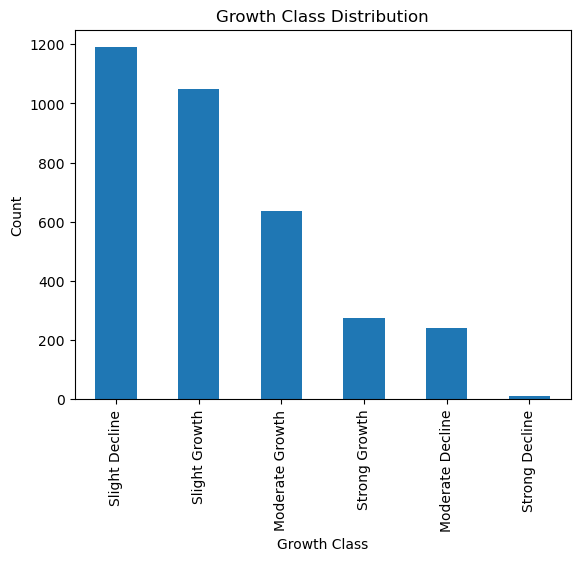

In [24]:
import matplotlib.pyplot as plt

df['Growth_Class'].value_counts().plot(kind='bar')

plt.title("Growth Class Distribution")

plt.xlabel("Growth Class")
plt.ylabel("Count")

plt.show()

In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))
# Precision Meaning: When the model predicts something, how often is it correct?
# Recall Meaning: How many real cases did the model successfully find?
# F1-Score Meaning: Balance between Precision and Recall

                  precision    recall  f1-score   support

Moderate Decline       0.89      0.86      0.88        58
 Moderate Growth       0.82      0.91      0.86       109
  Slight Decline       0.89      0.87      0.88       258
   Slight Growth       0.85      0.84      0.85       203
  Strong Decline       0.00      0.00      0.00         1
   Strong Growth       0.92      0.88      0.90        52

        accuracy                           0.87       681
       macro avg       0.73      0.73      0.73       681
    weighted avg       0.87      0.87      0.87       681



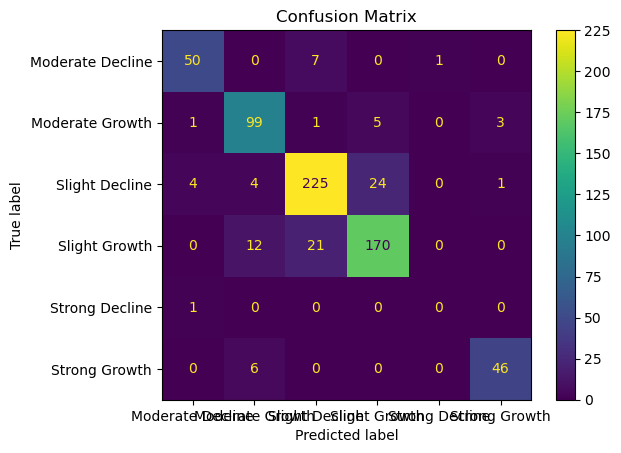

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test)

plt.title("Confusion Matrix")

plt.show()

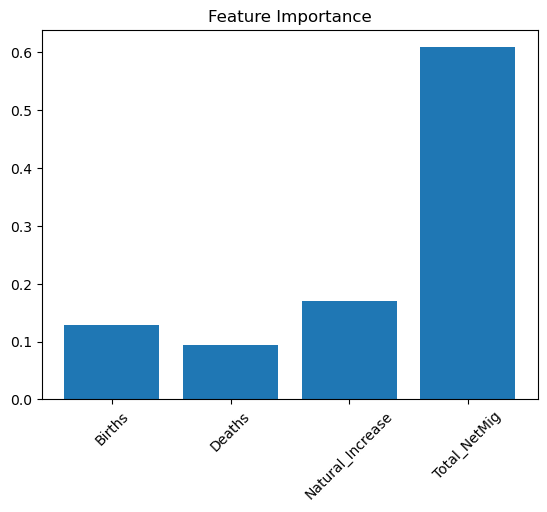

In [30]:
importance = model.feature_importances_

features = X.columns
plt.bar(features, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

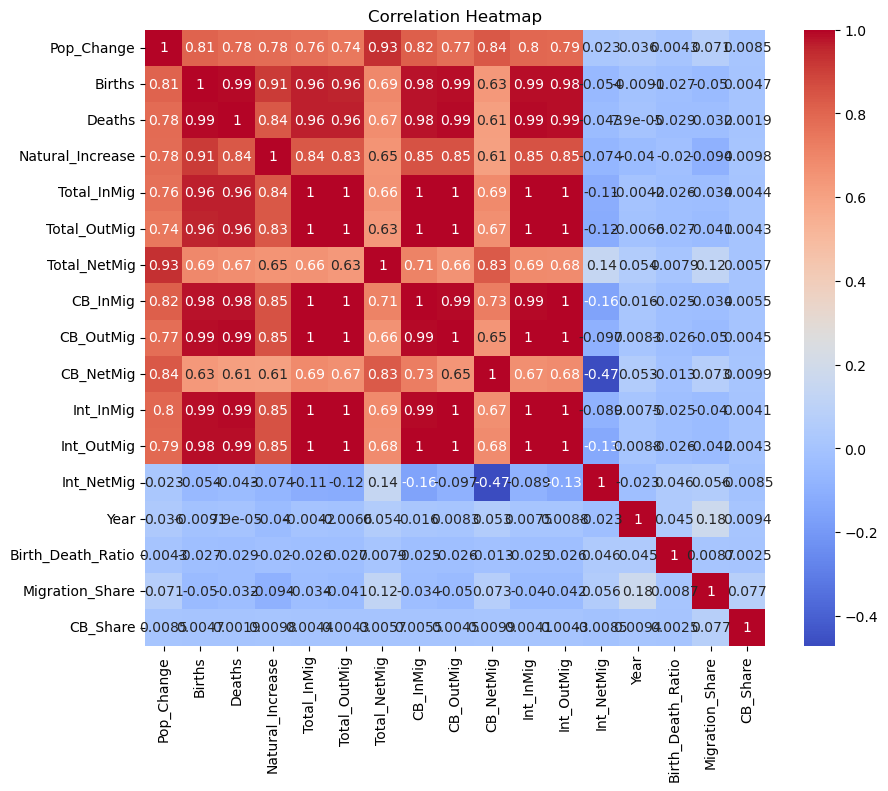

In [31]:
import seaborn as sns

numeric_df = df.select_dtypes(include='number')

corr = numeric_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
# Conclusion

# The machine learning model successfully classified population growth patterns using demographic and migration-related features. 
# The project demonstrates how data preprocessing, feature engineering, and classification models can support urban population analysis.